# Covariables Principales

In [2]:
import os
import numpy as np
import xarray as xr
import rioxarray
import geopandas as gpd
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


## Precipitación 

Procesando 2017...
Procesando 2018...
Procesando 2019...
Procesando 2020...
Procesando 2021...
Procesando 2022...
Procesando 2023...


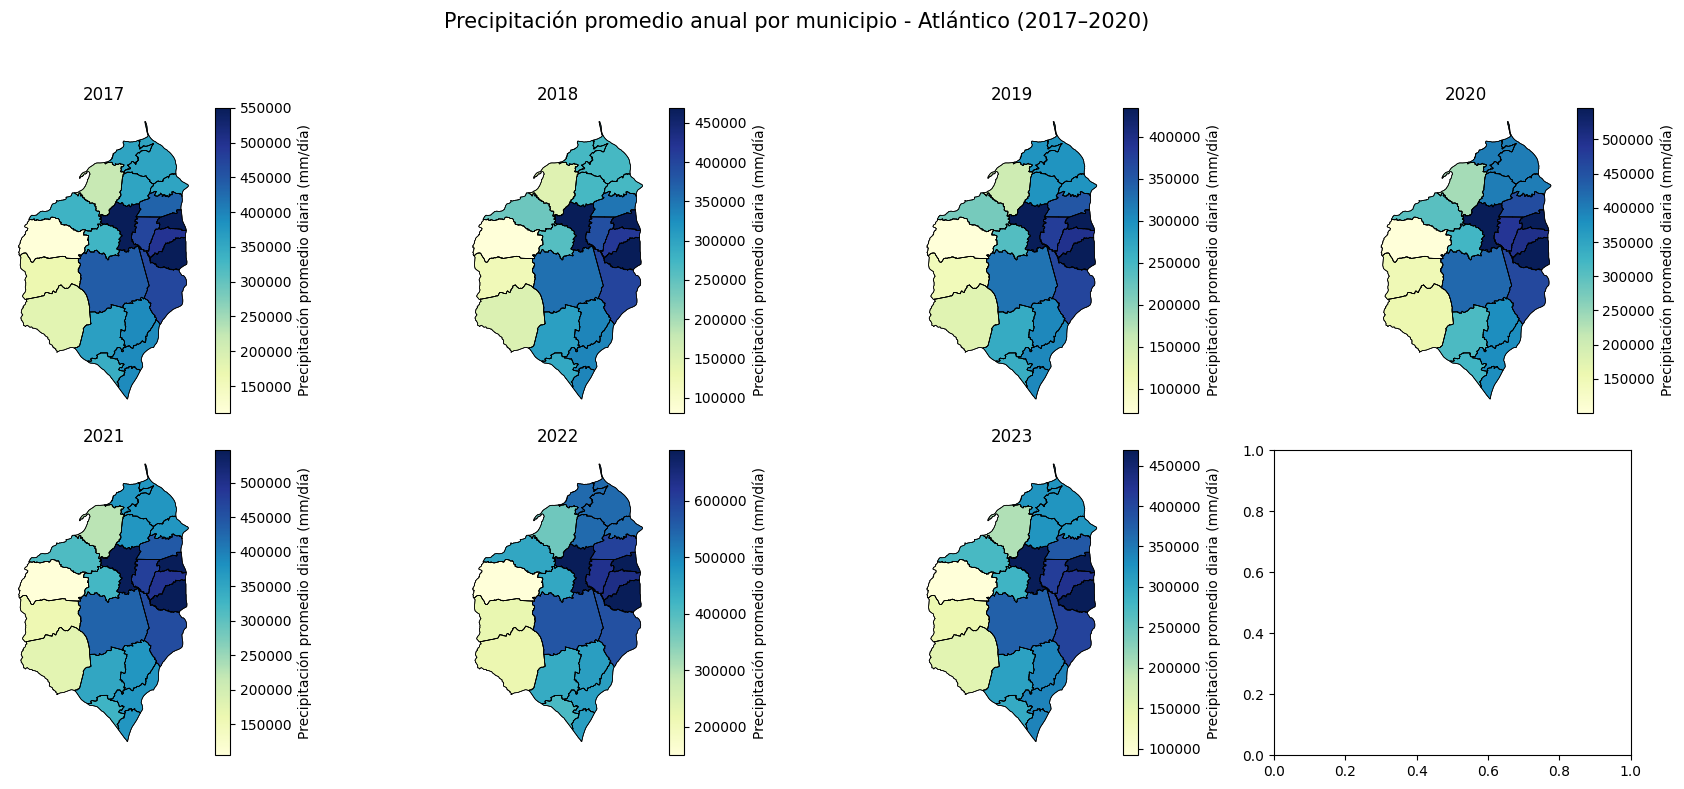

In [12]:
# ------------------------------------------------------------
# 🌧️ Precipitación promedio anual (2017–2020) con escalas individuales
# ------------------------------------------------------------

import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from rasterstats import zonal_stats
import rioxarray

# ------------------------------------------------------------
# 1️⃣ Configuración base
# ------------------------------------------------------------
rutas = {
    2017: r"C:\Dengue\Datos Clima\precipitacion_atl_2017",
    2018: r"C:\Dengue\Datos Clima\precipitacion_atl_2018",
    2019: r"C:\Dengue\Datos Clima\precipitacion_atl_2019",
    2020: r"C:\Dengue\Datos Clima\precipitacion_atl_2020",
    2021: r"C:\Dengue\Datos Clima\precipitacion_atl_2021",
    2022: r"C:\Dengue\Datos Clima\precipitacion_atl_2022",
    2023: r"C:\Dengue\Datos Clima\precipitacion_atl_2023"
}

# Shapefile del Atlántico
gdf_base = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding="utf-8")
gdf_base = gdf_base.rename(columns={'mpio_cnmbr': 'municipio'})
gdf_base = gdf_base[gdf_base['dpto_cnmbr'].str.upper() == 'ATLÁNTICO']

# Figura con 4 subplots (2x2)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
cmap = "YlGnBu"

# ------------------------------------------------------------
# 2️⃣ Procesar y graficar cada año con su escala
# ------------------------------------------------------------
for i, (anio, ruta) in enumerate(rutas.items()):
    print(f"Procesando {anio}...")

    # Abrir dataset (todos los archivos del año)
    ds = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")

    # Variable principal (precipitación)
    var = ds["Precipitation_Flux"].rio.write_crs("EPSG:4326")

    # Convertir unidades a mm/día (si está en kg m⁻² s⁻¹)
    var_mm_dia = var * 86400

    # Promedio anual
    promedio_anual = var_mm_dia.mean(dim="time")

    # Guardar raster temporal
    temp_raster = fr"C:\Dengue\Datos Clima\figs\precipitacion_promedio_anual_{anio}.tif"
    promedio_anual.rio.to_raster(temp_raster)

    # Copiar shapefile
    gdf = gdf_base.copy()

    # Calcular media zonal por municipio
    stats = zonal_stats(gdf, temp_raster, stats="mean", nodata=np.nan)
    gdf["precipitacion_promedio"] = [s["mean"] for s in stats]


    # ------------------------------------------------------------
    # 🔧 Aproximar municipios sin datos con promedio de 5 vecinos más cercanos
    # ------------------------------------------------------------
    from shapely.ops import nearest_points
    from shapely.geometry import Point

    # Centroides de cada municipio
    gdf["centroide"] = gdf.geometry.centroid

    # Municipios con y sin datos
    gdf_con_datos = gdf.dropna(subset=["precipitacion_promedio"])
    gdf_sin_datos = gdf[gdf["precipitacion_promedio"].isna()]

    # Para cada municipio sin datos, estimar valor según 5 vecinos más cercanos
    for idx, row in gdf_sin_datos.iterrows():
        # Calcular distancias a todos los municipios con datos
        gdf_con_datos["dist"] = gdf_con_datos["centroide"].distance(row["centroide"])
        vecinos_cercanos = gdf_con_datos.nsmallest(5, "dist")

        # Promedio de precipitación de los 5 vecinos
        valor_aprox = vecinos_cercanos["precipitacion_promedio"].mean()
        gdf.at[idx, "precipitacion_promedio"] = valor_aprox

    # Limpieza
    gdf.drop(columns="centroide", inplace=True)


    # ------------------------------------------------------------
    # 3️⃣ Graficar cada año con su propia escala
    # ------------------------------------------------------------
    ax = axes[i]
    gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

    gdf.plot(
        column="precipitacion_promedio",
        cmap=cmap,
        legend=True,
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
        legend_kwds={
            "label": "Precipitación promedio diaria (mm/día)",
            "orientation": "vertical"
        },
        missing_kwds={"color": "white", "edgecolor": "black", "hatch": "///", "label": "Sin datos"}
    )

    ax.set_title(f"{anio}", fontsize=12)
    ax.axis("off")

# ------------------------------------------------------------
# 4️⃣ Ajustes finales
# ------------------------------------------------------------
plt.suptitle("Precipitación promedio anual por municipio - Atlántico (2017–2020)", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Humedad

Procesando 2017...
Procesando 2018...
Procesando 2019...
Procesando 2020...
Procesando 2021...
Procesando 2022...
Procesando 2023...


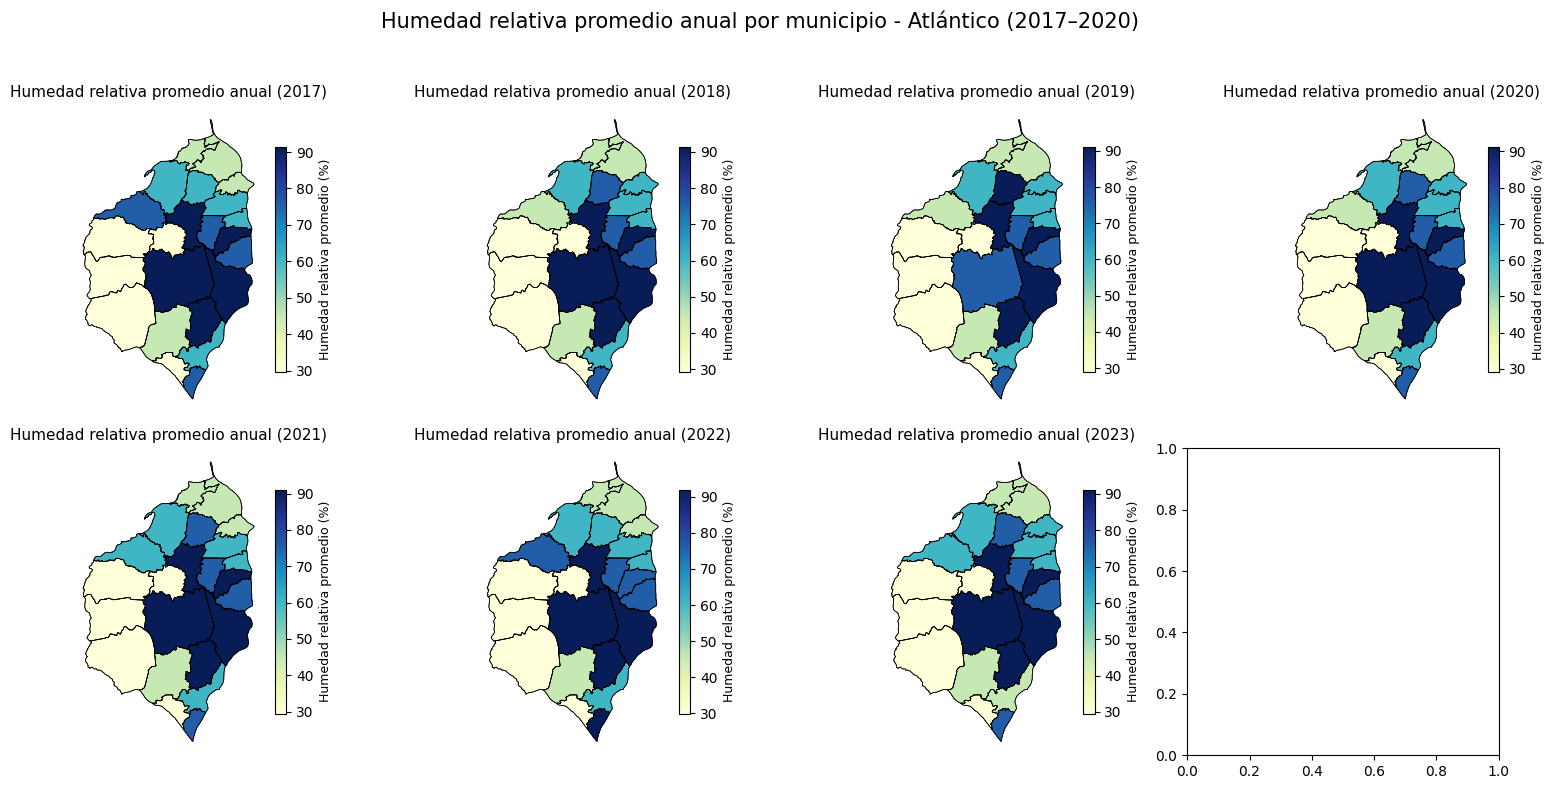

In [11]:
# ------------------------------------------------------------
# 💧 Humedad relativa promedio anual (2017–2020) - Atlántico
# Con escalas individuales (colorbars)
# ------------------------------------------------------------

import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from rasterstats import zonal_stats
import mapclassify
import rioxarray

# ------------------------------------------------------------
# 1️⃣ Directorios por año
# ------------------------------------------------------------
rutas = {
    2017: r"C:\Dengue\Datos Clima\humedad_atl_2017",
    2018: r"C:\Dengue\Datos Clima\humedad_atl_2018",
    2019: r"C:\Dengue\Datos Clima\humedad_atl_2019",
    2020: r"C:\Dengue\Datos Clima\humedad_atl_2020",
    2021: r"C:\Dengue\Datos Clima\humedad_atl_2021",
    2022: r"C:\Dengue\Datos Clima\humedad_atl_2022",
    2023: r"C:\Dengue\Datos Clima\humedad_atl_2023"
}

# ------------------------------------------------------------
# 2️⃣ Cargar shapefile del Atlántico
# ------------------------------------------------------------
gdf_base = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding="utf_8")
gdf_base = gdf_base.rename(columns={'mpio_cnmbr': 'municipio'})
gdf_base = gdf_base[gdf_base['dpto_cnmbr'] == 'ATLÁNTICO']

# ------------------------------------------------------------
# 3️⃣ Figura 2x2
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
cmap = "YlGnBu"

# ------------------------------------------------------------
# 4️⃣ Procesar cada año
# ------------------------------------------------------------
for i, (anio, ruta) in enumerate(rutas.items()):
    print(f"Procesando {anio}...")

    # Cargar datos netCDF
    ds = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")

    # Variable: humedad relativa a 2 m (06h)
    var = ds["Relative_Humidity_2m_06h"].rio.write_crs("EPSG:4326")

    # Promedio anual
    promedio_anual = var.mean(dim="time")

    # Guardar raster temporal
    temp_raster = fr"C:\Dengue\Datos Clima\figs\humedad_promedio_anual_atl_{anio}.tif"
    promedio_anual.rio.to_raster(temp_raster)

    # Copiar shapefile
    gdf = gdf_base.copy()

    # Estadísticos zonales
    stats = zonal_stats(
        gdf,
        temp_raster,
        stats="mean",
        nodata=np.nan
    )
    gdf["humedad_promedio"] = [s["mean"] for s in stats]
    
    # ------------------------------------------------------------
    # 🔧 Aproximar municipios sin datos con promedio de 5 vecinos más cercanos
    # ------------------------------------------------------------
    from shapely.ops import nearest_points
    from shapely.geometry import Point

    # Calcular centroides
    gdf["centroide"] = gdf.geometry.centroid

    # Separar municipios con y sin datos
    gdf_con_datos = gdf.dropna(subset=["humedad_promedio"])
    gdf_sin_datos = gdf[gdf["humedad_promedio"].isna()]

    # Para cada municipio sin datos, estimar el valor según sus 5 vecinos más cercanos
    for idx, row in gdf_sin_datos.iterrows():
        # Calcular distancias a los municipios con datos
        gdf_con_datos["dist"] = gdf_con_datos["centroide"].distance(row["centroide"])
        vecinos_cercanos = gdf_con_datos.nsmallest(5, "dist")

        # Calcular promedio simple de la humedad de los vecinos
        valor_aprox = vecinos_cercanos["humedad_promedio"].mean()

        # Asignar valor aproximado
        gdf.at[idx, "humedad_promedio"] = valor_aprox

    # Eliminar la columna auxiliar
    gdf.drop(columns="centroide", inplace=True)


    # ------------------------------------------------------------
    # 5️⃣ Graficar
    # ------------------------------------------------------------
    ax = axes[i]

    # Bordes
    gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

    # Capa principal
    gdf_plot = gdf.plot(
        column="humedad_promedio",
        cmap=cmap,
        scheme="Quantiles",
        k=5,
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
        missing_kwds={
            "color": "white",
            "edgecolor": "black",
            "hatch": "///",
            "label": "Sin datos"
        }
    )

    # Escala de colores individual
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(
            vmin=gdf["humedad_promedio"].min(),
            vmax=gdf["humedad_promedio"].max()
        )
    )
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.036, pad=0.04)
    cbar.set_label("Humedad relativa promedio (%)", fontsize=9)

    # Título y estilo
    ax.set_title(f"Humedad relativa promedio anual ({anio})", fontsize=11)
    ax.axis("off")

# ------------------------------------------------------------
# 6️⃣ Ajustes finales
# ------------------------------------------------------------
plt.suptitle("Humedad relativa promedio anual por municipio - Atlántico (2017–2020)",
             fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



## Temperatura

### Maxima

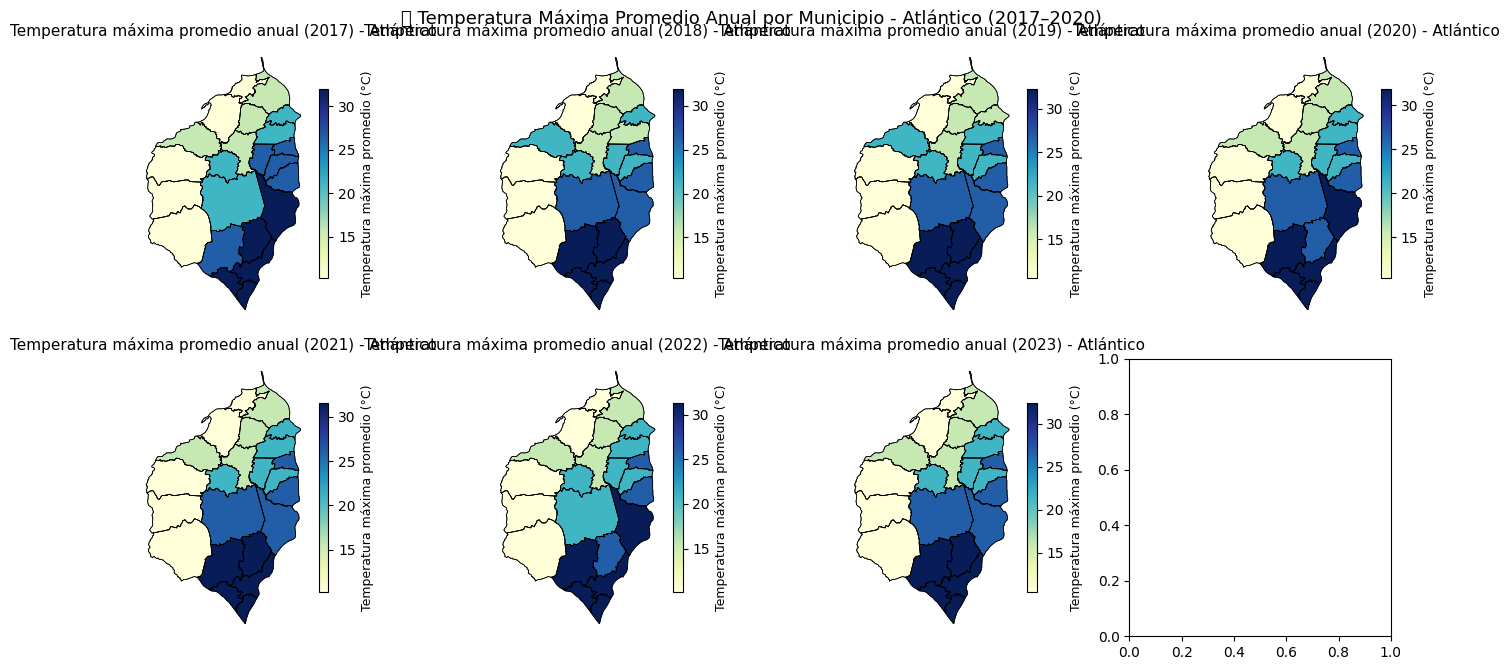

In [14]:
# ------------------------------------------------------------
# 🌡️ Temperatura Máxima Promedio Anual (2017–2020) - Atlántico
# ------------------------------------------------------------
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import xarray as xr
import os
import mapclassify

# ------------------------------------------------------------
# 1️⃣ Configuración general
# ------------------------------------------------------------
años = [2017, 2018, 2019, 2020,2021,2022,2023]
base_path = r"C:\Dengue\Datos Clima"
shapefile = r"Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp"

# Cargar shapefile del Atlántico
gdf_base = gpd.read_file(shapefile, encoding="utf_8")
gdf_base = gdf_base.rename(columns={'mpio_cnmbr': 'municipio'})
gdf_base = gdf_base[gdf_base['dpto_cnmbr'] == 'ATLÁNTICO']

# ------------------------------------------------------------
# 2️⃣ Crear figura 2x2 y aplanar ejes
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()  # ✅ para recorrer con un solo índice

# ------------------------------------------------------------
# 3️⃣ Procesar cada año
# ------------------------------------------------------------
for i, año in enumerate(años):
    ruta = fr"{base_path}\temp_max_atl_{año}"

    # Abrir todos los .nc del año y combinarlos
    archivos_nc = [os.path.join(ruta, f) for f in os.listdir(ruta) if f.endswith(".nc")]
    ds = xr.open_mfdataset(archivos_nc, combine="by_coords")

    # Variable de temperatura máxima (convertir de Kelvin a °C)
    var = ds["Temperature_Air_2m_Max_24h"].rio.write_crs("EPSG:4326") - 273.15

    # Promedio anual
    promedio_anual = var.mean(dim="time")

    # Guardar raster temporal
    temp_raster = fr"{base_path}\figs\temp_max_promedio_anual_atl_{año}.tif"
    promedio_anual.rio.to_raster(temp_raster)

    # Copiar shapefile base
    gdf = gdf_base.copy()

    # Calcular promedio por municipio
    stats = zonal_stats(
        gdf,
        temp_raster,
        stats="mean",
        nodata=np.nan
    )
    gdf["temp_max_promedio"] = [s["mean"] for s in stats]
    
    # ------------------------------------------------------------
    # 🔧 Aproximar municipios sin datos con promedio de 5 vecinos más cercanos
    # ------------------------------------------------------------
    from shapely.geometry import Point

    # Calcular centroides
    gdf["centroide"] = gdf.geometry.centroid

    # Separar municipios con y sin datos
    gdf_con_datos = gdf.dropna(subset=["temp_max_promedio"])
    gdf_sin_datos = gdf[gdf["temp_max_promedio"].isna()]

    # Para cada municipio sin datos, estimar el valor según 5 vecinos más cercanos
    for idx, row in gdf_sin_datos.iterrows():
        # Calcular distancias a los municipios con datos
        gdf_con_datos["dist"] = gdf_con_datos["centroide"].distance(row["centroide"])
        vecinos_cercanos = gdf_con_datos.nsmallest(3, "dist")

        # Promedio simple de temperatura máxima de los vecinos
        valor_aprox = vecinos_cercanos["temp_max_promedio"].mean()

        # Asignar valor aproximado
        gdf.at[idx, "temp_max_promedio"] = valor_aprox

    # Eliminar columna auxiliar
    gdf.drop(columns="centroide", inplace=True)


    # --------------------------------------------------------
    # Graficar mapa
    # --------------------------------------------------------
    ax = axes[i]
    cmap = "YlGnBu"

    gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)
    gdf_plot = gdf.plot(
        column="temp_max_promedio",
        cmap=cmap,
        scheme="Quantiles",
        k=5,
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
        missing_kwds={
            "color": "white",
            "edgecolor": "black",
            "hatch": "///",
            "label": "Sin datos"
        }
    )

    # Escala de colores individual
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(
            vmin=gdf["temp_max_promedio"].min(),
            vmax=gdf["temp_max_promedio"].max()
        )
    )
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.036, pad=0.04)
    cbar.set_label("Temperatura máxima promedio (°C)", fontsize=9)

    # Título y estilo
    ax.set_title(f"Temperatura máxima promedio anual ({año}) - Atlántico", fontsize=11)
    ax.axis("off")

# ------------------------------------------------------------
# 4️⃣ Ajuste final
# ------------------------------------------------------------
plt.suptitle("🌡️ Temperatura Máxima Promedio Anual por Municipio - Atlántico (2017–2020)",
             fontsize=13, y=0.95)
plt.tight_layout()
plt.show()


### Minima

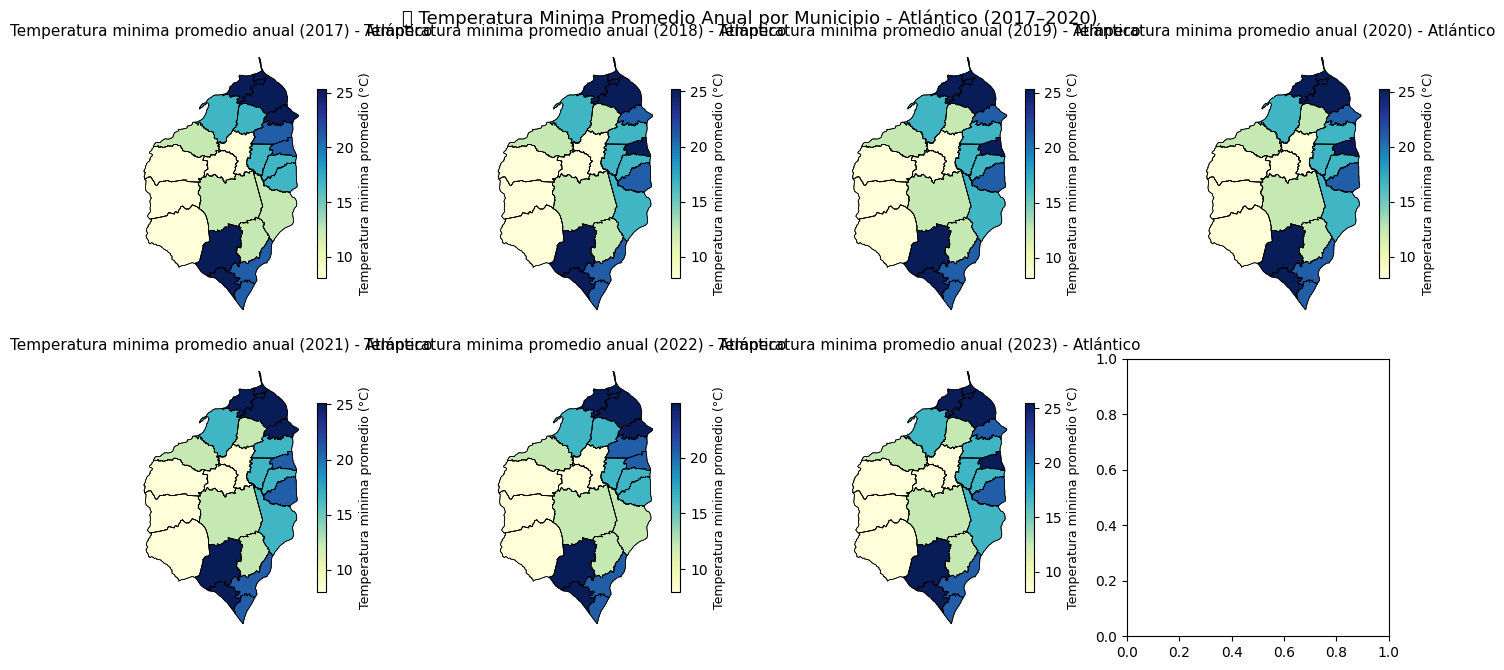

In [15]:
# ------------------------------------------------------------
# 🌡️ Temperatura Máxima Promedio Anual (2017–2020) - Atlántico
# ------------------------------------------------------------
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import xarray as xr
import os
import mapclassify

# ------------------------------------------------------------
# 1️⃣ Configuración general
# ------------------------------------------------------------
años = [2017, 2018, 2019, 2020, 2021, 2022, 2023]
base_path = r"C:\Dengue\Datos Clima"
shapefile = r"Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp"

# Cargar shapefile del Atlántico
gdf_base = gpd.read_file(shapefile, encoding="utf_8")
gdf_base = gdf_base.rename(columns={'mpio_cnmbr': 'municipio'})
gdf_base = gdf_base[gdf_base['dpto_cnmbr'] == 'ATLÁNTICO']

# ------------------------------------------------------------
# 2️⃣ Crear figura 2x2 y aplanar ejes
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()  # ✅ para recorrer con un solo índice

# ------------------------------------------------------------
# 3️⃣ Procesar cada año
# ------------------------------------------------------------
for i, año in enumerate(años):
    ruta = fr"{base_path}\temp_min_atl_{año}"

    # Abrir todos los .nc del año y combinarlos
    archivos_nc = [os.path.join(ruta, f) for f in os.listdir(ruta) if f.endswith(".nc")]
    ds = xr.open_mfdataset(archivos_nc, combine="by_coords")

    # Variable de temperatura máxima (convertir de Kelvin a °C)
    var = ds["Temperature_Air_2m_Min_24h"].rio.write_crs("EPSG:4326") - 273.15

    # Promedio anual
    promedio_anual = var.mean(dim="time")

    # Guardar raster temporal
    temp_raster = fr"{base_path}\figs\temp_max_promedio_anual_atl_{año}.tif"
    promedio_anual.rio.to_raster(temp_raster)

    # Copiar shapefile base
    gdf = gdf_base.copy()

    # Calcular promedio por municipio
    stats = zonal_stats(
        gdf,
        temp_raster,
        stats="mean",
        nodata=np.nan
    )
    gdf["temp_min_promedio"] = [s["mean"] for s in stats]
    
    # ------------------------------------------------------------
    # 🔧 Aproximar municipios sin datos con promedio de 5 vecinos más cercanos
    # ------------------------------------------------------------
    from shapely.geometry import Point

    # Calcular centroides
    gdf["centroide"] = gdf.geometry.centroid

    # Separar municipios con y sin datos
    gdf_con_datos = gdf.dropna(subset=["temp_min_promedio"])
    gdf_sin_datos = gdf[gdf["temp_min_promedio"].isna()]

    # Para cada municipio sin datos, estimar el valor según 5 vecinos más cercanos
    for idx, row in gdf_sin_datos.iterrows():
        # Calcular distancias a los municipios con datos
        gdf_con_datos["dist"] = gdf_con_datos["centroide"].distance(row["centroide"])
        vecinos_cercanos = gdf_con_datos.nsmallest(3, "dist")

        # Promedio simple de temperatura máxima de los vecinos
        valor_aprox = vecinos_cercanos["temp_min_promedio"].mean()

        # Asignar valor aproximado
        gdf.at[idx, "temp_min_promedio"] = valor_aprox

    # Eliminar columna auxiliar
    gdf.drop(columns="centroide", inplace=True)


    # --------------------------------------------------------
    # Graficar mapa
    # --------------------------------------------------------
    ax = axes[i]
    cmap = "YlGnBu"

    gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)
    gdf_plot = gdf.plot(
        column="temp_min_promedio",
        cmap=cmap,
        scheme="Quantiles",
        k=5,
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
        missing_kwds={
            "color": "white",
            "edgecolor": "black",
            "hatch": "///",
            "label": "Sin datos"
        }
    )

    # Escala de colores individual
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(
            vmin=gdf["temp_min_promedio"].min(),
            vmax=gdf["temp_min_promedio"].max()
        )
    )
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.036, pad=0.04)
    cbar.set_label("Temperatura minima promedio (°C)", fontsize=9)

    # Título y estilo
    ax.set_title(f"Temperatura minima promedio anual ({año}) - Atlántico", fontsize=11)
    ax.axis("off")

# ------------------------------------------------------------
# 4️⃣ Ajuste final
# ------------------------------------------------------------
plt.suptitle("🌡️ Temperatura Minima Promedio Anual por Municipio - Atlántico (2017–2020)",
             fontsize=13, y=0.95)
plt.tight_layout()
plt.show()


# Covariables opcionales

## Distancia a los ríos

In [ ]:
import geopandas as gpd

# --- Municipios del Atlántico ---
gdf_mpios = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp")
gdf_mpios = gdf_mpios[gdf_mpios["dpto_cnmbr"].str.upper() == "ATLÁNTICO"]

# --- HydroRIVERS Sudamérica ---
rios_sa = gpd.read_file(r"C:\Dengue\Datos Clima\HydroRIVERS_v10_sa_shp\HydroRIVERS_v10_sa_shp\HydroRIVERS_v10_sa.shp")

print(len(rios_sa), "segmentos de río en Sudamérica")


1620963 segmentos de río en Sudamérica


In [3]:
# Unión del contorno del Atlántico (un solo polígono)
atlantico_union = gdf_mpios.unary_union.buffer(0.5)

# Recortar los ríos
rios_atl = gpd.clip(rios_sa, atlantico_union)

print(len(rios_atl), "ríos dentro o cerca del Atlántico")


C:\Users\TAWTOCA\AppData\Local\Temp\ipykernel_15944\3944452838.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  atlantico_union = gdf_mpios.unary_union.buffer(0.5)


807 ríos dentro o cerca del Atlántico


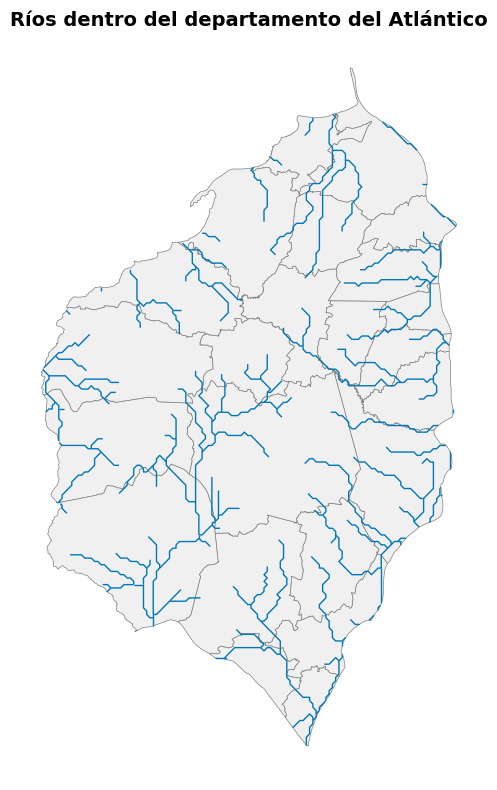

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# --- Cargar shapefiles ---
gdf_mpios = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp")
gdf_mpios = gdf_mpios[gdf_mpios["dpto_cnmbr"].str.upper() == "ATLÁNTICO"]

rios = gpd.read_file(r"C:\Dengue\Datos Clima\HydroRIVERS_v10_sa_shp\HydroRIVERS_v10_sa_shp\HydroRIVERS_v10_sa.shp")


# --- Asegurar CRS iguales ---
rios = rios.to_crs(gdf_mpios.crs)

# --- Recortar ríos al Atlántico ---
rios_clip = gpd.clip(rios, gdf_mpios)

# --- Graficar resultado ---
fig, ax = plt.subplots(figsize=(8, 8))
gdf_mpios.plot(ax=ax, color="#f0f0f0", edgecolor="gray", linewidth=0.5)
rios_clip.plot(ax=ax, color="#0077b6", linewidth=1)

# Etiquetas opcionales
#for x, y, label in zip(gdf_mpios.geometry.centroid.x, gdf_mpios.geometry.centroid.y, gdf_mpios["mpio_cnmbr"]):
 #   ax.text(x, y, label, fontsize=8, ha='center', color='dimgray')

ax.set_title("Ríos dentro del departamento del Atlántico", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()




In [11]:
# Guardar shapefile
rios_clip.to_file(r"C:\Dengue\Datos Clima\HydroRIVERS_Atlantico.shp")

In [13]:
import geopandas as gpd
from shapely.ops import nearest_points
import pandas as pd

# --- Cargar shapefiles (ya recortados) ---
gdf_mpios = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp")
gdf_mpios = gdf_mpios[gdf_mpios["dpto_cnmbr"].str.upper() == "ATLÁNTICO"]

rios_clip = gpd.read_file(r"C:\Dengue\Datos Clima\HydroRIVERS_Atlantico.shp")

# --- Asegurar CRS proyectado (para medir en metros) ---
gdf_mpios = gdf_mpios.to_crs(3116)  # EPSG:3116 = Colombia Bogotá / MAGNA-SIRGAS
rios_clip = rios_clip.to_crs(3116)

# --- Calcular centroides de municipios ---
gdf_mpios["centroide"] = gdf_mpios.geometry.centroid

# --- Calcular distancia mínima al río más cercano ---
distancias = []
for i, row in gdf_mpios.iterrows():
    punto = row["centroide"]
    distancia_min = rios_clip.distance(punto).min()
    distancias.append(distancia_min)

# --- Agregar resultado ---
gdf_mpios["dist_rio_mas_cercano_m"] = distancias
gdf_mpios["dist_rio_mas_cercano_km"] = gdf_mpios["dist_rio_mas_cercano_m"] / 1000

# --- Ver resultado ---
print(gdf_mpios[["mpio_cnmbr", "dist_rio_mas_cercano_km"]].sort_values("dist_rio_mas_cercano_km"))

# --- Guardar shapefile con la covariable ---
gdf_out = gdf_mpios.drop(columns=["centroide"])
gdf_out.to_file(r"C:\Dengue\Datos Clima\covariable_distancia_rio.shp")


           mpio_cnmbr  dist_rio_mas_cercano_km
136         POLONUEVO                 0.058358
145              SUAN                 0.096866
137          PONEDERA                 0.099086
127  CAMPO DE LA CRUZ                 0.262272
140      SABANAGRANDE                 0.574154
134  PALMAR DE VARELA                 0.692781
141       SABANALARGA                 0.705267
129            GALAPA                 0.728151
147          USIACURÍ                 0.849956
132           MALAMBO                 0.963124
128        CANDELARIA                 1.044205
126           BARANOA                 1.275987
139           REPELÓN                 1.438214
133            MANATÍ                 1.595382
130    JUAN DE ACOSTA                 1.859178
138   PUERTO COLOMBIA                 1.902684
131           LURUACO                 1.906557
125      BARRANQUILLA                 1.991481
144           SOLEDAD                 2.112103
142       SANTA LUCÍA                 2.134185
146          

C:\Users\TAWTOCA\AppData\Local\Temp\ipykernel_15944\2965599335.py:34: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_out.to_file(r"C:\Dengue\Datos Clima\covariable_distancia_rio.shp")
C:\Users\TAWTOCA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'dist_rio_mas_cercano_m' to 'dist_rio_m'
  ogr_write(
C:\Users\TAWTOCA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'dist_rio_mas_cercano_km' to 'dist_rio_1'
  ogr_write(


## Distancia a cuerpos de agua


In [14]:
gdf_mpios = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp")
gdf_mpios = gdf_mpios[gdf_mpios["dpto_cnmbr"].str.upper() == "ATLÁNTICO"]

In [25]:
lagos = gpd.read_file(r"C:\Dengue\Datos Clima\HydroLAKES_polys_v10_shp\HydroLAKES_polys_v10_shp\HydroLAKES_polys_v10.shp")

In [ ]:
lagos = lagos[lagos['Country']== 'Colombia']

In [18]:
lagos.head()

,Hylak_id,Lake_name,Country,Continent,Poly_src,Lake_type,Grand_id,Lake_area,Shore_len,Shore_dev,...,Vol_src,Depth_avg,Dis_avg,Res_time,Elevation,Slope_100,Wshd_area,Pour_long,Pour_lat,geometry
870,871,None,Colombia,South America,SWBD,1,0,102.00,136.23,3.81,...,3,1.2,7.420,196.9,0,0.31,731.8,-74.496875,10.771398,"POLYGON ((-74.58018 10.87506, -74.57917 10.874..."
871,872,Guajaro,Colombia,South America,SWBD,1,0,112.88,159.74,4.24,...,3,3.2,3.074,1355.1,4,0.69,903.1,-75.107292,10.411269,"POLYGON ((-75.08834 10.62027, -75.08721 10.619..."
875,876,Zapatosa,Colombia,South America,SWBD,1,0,286.55,485.70,8.09,...,3,3.8,357.088,35.6,22,0.66,22165.8,-73.901387,9.052081,"POLYGON ((-73.76055 9.27889, -73.76024 9.27695..."
876,877,None,Colombia,South America,SWBD,1,0,130.04,276.82,6.85,...,3,1.2,6508.218,0.3,10,0.29,225595.1,-74.666475,9.050205,"POLYGON ((-74.70027 9.0476, -74.6989 9.04445, ..."
877,878,None,Colombia,South America,SWBD,1,0,199.42,372.74,7.45,...,3,1.3,449.270,6.5,11,0.27,16920.7,-74.769634,9.019717,"POLYGON ((-74.7875 9.03722, -74.78691 9.03639,..."


(-75.27608638228685,
 -74.69177031892411,
 10.210681856904984,
 11.147974602698362)

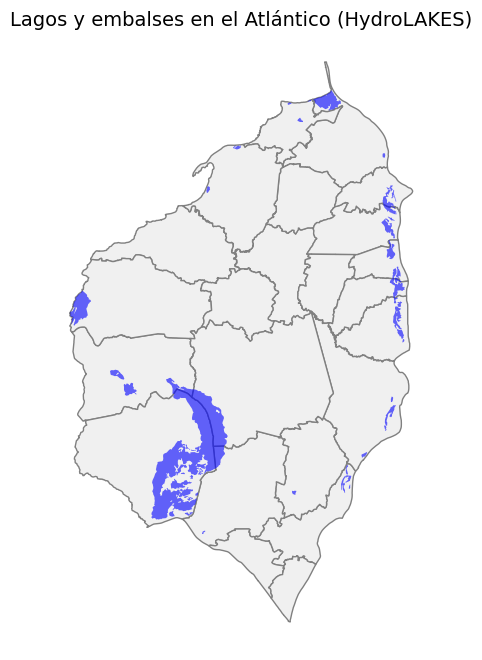

In [19]:

lakes_clip = gpd.clip(lagos, gdf_mpios)

# Visualizar
ax = gdf_mpios.plot(color="#f0f0f0", edgecolor="gray", figsize=(8,8))
lakes_clip.plot(ax=ax, color="blue", alpha=0.6)
ax.set_title("Lagos y embalses en el Atlántico (HydroLAKES)", fontsize=14)
ax.axis("off")


C:\Users\TAWTOCA\AppData\Local\Temp\ipykernel_15944\3056364916.py:35: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  lagos_union = lagos_utm.unary_union
C:\Users\TAWTOCA\AppData\Local\Temp\ipykernel_15944\3056364916.py:61: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\TAWTOCA\AppData\Local\Temp\ipykernel_15944\3056364916.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


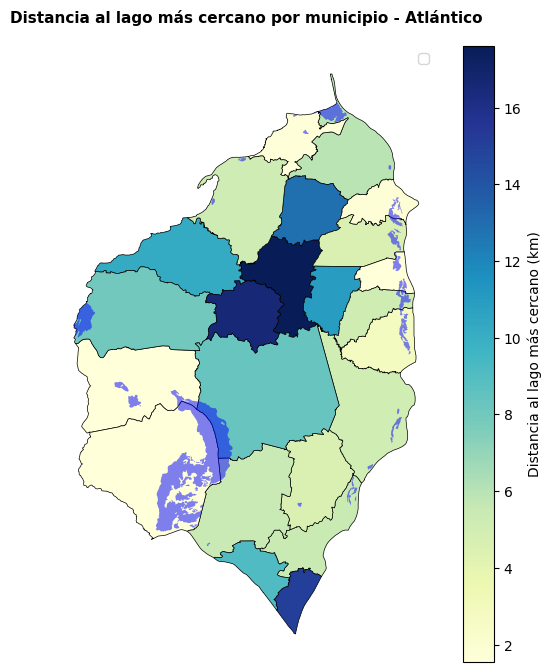

In [ ]:
# ------------------------------------------------------------
# 🌊 Distancia al lago o embalse más cercano (HydroLAKES)
# ------------------------------------------------------------
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import nearest_points

# ------------------------------------------------------------
# 1️⃣ Cargar datos
# ------------------------------------------------------------
# Capa de municipios del Atlántico
municpios = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp")
municipios = gdf_mpios[gdf_mpios["dpto_cnmbr"].str.upper() == "ATLÁNTICO"]
# Capa de lagos o embalses (HydroLAKES shapefile)
lagos = lagos[lagos['Country']== 'Colombia']
# Filtrar solo los lagos dentro o cerca del Atlántico
lagos = lagos.to_crs(municipios.crs)
lagos = gpd.clip(lagos, municipios)

# ------------------------------------------------------------
# 2️⃣ Reproyectar a coordenadas métricas (UTM zona 18N)
# ------------------------------------------------------------
municipios_utm = municipios.to_crs(epsg=32618)
lagos_utm = lagos.to_crs(epsg=32618)

# ------------------------------------------------------------
# 3️⃣ Calcular centroides de municipios
# ------------------------------------------------------------
municipios_utm["centroide"] = municipios_utm.centroid

# ------------------------------------------------------------
# 4️⃣ Calcular distancia al lago más cercano
# ------------------------------------------------------------
# Para eficiencia: convertir geometrías a una sola colección (MultiPolygon)
lagos_union = lagos_utm.unary_union

municipios_utm["dist_lago_m"] = municipios_utm["centroide"].apply(
    lambda x: x.distance(lagos_union)
)

# Convertir a kilómetros si prefieres
municipios_utm["dist_lago_km"] = municipios_utm["dist_lago_m"] / 1000

# ------------------------------------------------------------
# 5️⃣ Visualización
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 8))
municipios_utm.plot(
    column="dist_lago_km",
    cmap="YlGnBu",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Distancia al lago más cercano (km)"},
    ax=ax
)
lagos_utm.plot(ax=ax, color="blue", alpha=0.5, label="Lagos y embalses")

ax.set_title("Distancia al lago más cercano por municipio - Atlántico", fontsize=11, weight="bold")
ax.axis("off")
ax.legend()
plt.show()


In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Cargar datos
zonas_hidro = gpd.read_file(r"C:\Dengue\Datos Clima\Zonificacion_Hidrografica_2022\Zonificacion Hidrografica 2022\SHAPE\h_znhd_2022_100K.shp")
atlantico = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp")
atlantico = atlantico[atlantico["dpto_cnmbr"].str.upper() == "ATLÁNTICO"]

zonas_hidro.head()

,OBJECTID,COD_AH,nom_ah,COD_ZH,nom_zh,COD_SZH,nom_szh,ruleid,SHAPE_Leng,SHAPE_Area,geometry
0,1,1.0,Caribe,11.0,Atrato - Darién,1101.0,Río Andágueda,2,1.807658,0.074302,"POLYGON ((-76.08487 5.68593, -76.08445 5.68528..."
1,2,1.0,Caribe,11.0,Atrato - Darién,1102.0,Alto Atrato,2,2.133416,0.134695,"POLYGON ((-76.09415 6.00418, -76.09405 6.0041,..."
2,3,1.0,Caribe,11.0,Atrato - Darién,1103.0,Río Quito,2,2.590285,0.150004,"POLYGON ((-76.54876 5.50406, -76.54956 5.50246..."
3,4,1.0,Caribe,11.0,Atrato - Darién,1104.0,Río Bebaramá y otros Directos Atrato (md = mar...,2,2.308334,0.212143,"POLYGON ((-76.23253 6.20106, -76.23226 6.20072..."
4,5,1.0,Caribe,11.0,Atrato - Darién,1105.0,Directos Atrato entre ríos Quito y Bojayá (mi ...,2,3.189538,0.251700,"POLYGON ((-76.85709 6.56619, -76.85325 6.56286..."


C:\Users\TAWTOCA\AppData\Local\Temp\ipykernel_15944\3930924051.py:10: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4686
Right CRS: EPSG:4326

  caribe_atlantico = gpd.clip(caribe, atlantico)


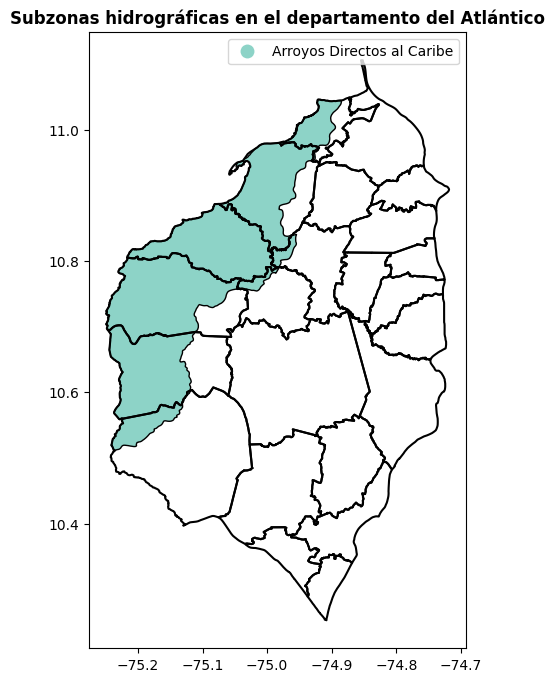

In [30]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Cargar zonificación hidrográfica del IDEAM
zonificacion = gpd.read_file(r"C:\Dengue\Datos Clima\Zonificacion_Hidrografica_2022\Zonificacion Hidrografica 2022\SHAPE\h_znhd_2022_100K.shp")
# Filtrar la zona Caribe (la que cubre Atlántico)
caribe = zonificacion[zonificacion["nom_ah"] == "Caribe"]


caribe_atlantico = gpd.clip(caribe, atlantico)

# Graficar
fig, ax = plt.subplots(figsize=(7,8))
caribe_atlantico.plot(ax=ax, column="nom_szh", cmap="Set3", legend=True, edgecolor="black")
atlantico.boundary.plot(ax=ax, color="black")
ax.set_title("Subzonas hidrográficas en el departamento del Atlántico", fontsize=12, weight="bold")
plt.show()
